# MLOps Assignment 2 — Cats vs Dogs

End-to-end pipeline

Not running in Colab — using current directory as project folder.
cwd: c:\Users\anant\Downloads\Mlops assignment 2
$ pip install -r requirements.txt -q
$ pip install dvc -q
cat: 300, dog: 300
$ git config --global user.name "Anantha Padmanabha"
$ git config --global user.email "YOUR_GITHUB_NOREPLY_EMAIL_HERE"
$ dvc init -f
$ dvc add data/raw
$ git add data/raw.dvc .gitignore
$ git commit -m "track raw dataset with DVC" --allow-empty
data/processed already exists — skipping.
Using device: cpu


c:\Users\anant\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch 1/5 train_loss=0.7998 val_loss=0.6789 val_acc=0.4833
epoch 2/5 train_loss=0.6696 val_loss=0.6559 val_acc=0.6000
epoch 3/5 train_loss=0.6042 val_loss=0.6972 val_acc=0.6000
epoch 4/5 train_loss=0.5615 val_loss=0.6041 val_acc=0.6000
epoch 5/5 train_loss=0.4830 val_loss=0.6921 val_acc=0.5667

Training complete. Model saved as catsdogs_model.pt
$ pytest tests/test_model.py -v
{'status': 'ok', 'model_loaded': True}
{'request_count': 0, 'avg_latency_ms': 0.0}


c:\Users\anant\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


$ git add .
$ git commit -m "pipeline run" --allow-empty
$ git branch -M main
$ git remote remove origin
$ git remote add origin https://github.com/Anantha-padmanabha-001/Assignment-2-MLOPS.git
$ git push -u origin main

Done. Token cleared from memory. Check your GitHub repo.


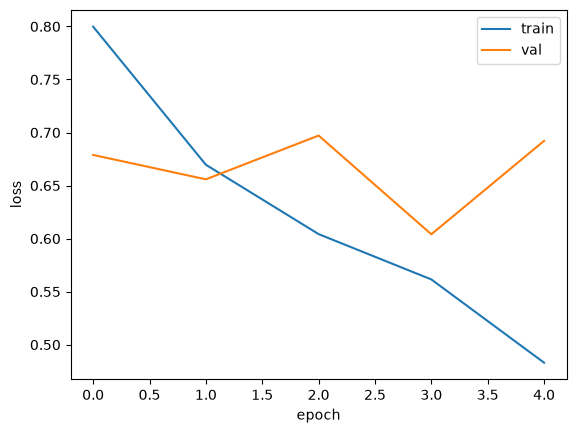

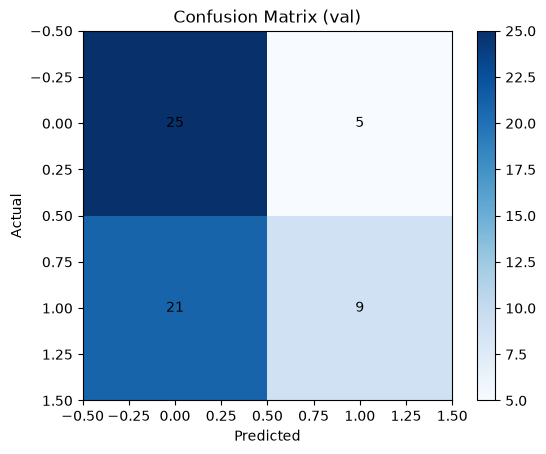

In [2]:

"""
MLOps Assignment 2 — Cats vs Dogs
End-to-end pipeline: data prep -> model training -> experiment tracking ->
packaging -> containerization -> CI/CD -> push to GitHub.

Run cells top to bottom. Works in Colab (mounts Drive) or locally in
Jupyter/VS Code (just skip the Drive-mount cell).
"""

# ============================================================
# 1. Mount Drive (Colab only — skip this cell if running locally)
# ============================================================
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = "/content/drive/My Drive/MLOps Assignment 2"
    os.makedirs(PROJECT_DIR, exist_ok=True)
    os.chdir(PROJECT_DIR)
except ImportError:
    print("Not running in Colab — using current directory as project folder.")

print("cwd:", os.getcwd())

# ============================================================
# 2. Install dependencies
# ============================================================
import subprocess

def run(cmd):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=False)

run("pip install -r requirements.txt -q")
run("pip install dvc -q")

# ============================================================
# 3. Dataset subset (adjust source paths if your folder names differ)
# ============================================================
import shutil, random

os.makedirs("data/raw/cat", exist_ok=True)
os.makedirs("data/raw/dog", exist_ok=True)

def copy_subset(src, dst, n=300):
    files = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(files)
    copied = 0
    for f in files[:n]:
        try:
            shutil.copy(os.path.join(src, f), os.path.join(dst, f))
            copied += 1
        except Exception:
            pass
    return copied

if os.path.exists("PetImages/Cat") and os.path.exists("PetImages/Dog"):
    n_cat = copy_subset("PetImages/Cat", "data/raw/cat", 300)
    n_dog = copy_subset("PetImages/Dog", "data/raw/dog", 300)
    print(f"cat: {n_cat}, dog: {n_dog}")
else:
    print("PetImages not found — skipping. Assuming data/raw/cat and data/raw/dog already populated.")
    print("cat:", len(os.listdir("data/raw/cat")) if os.path.exists("data/raw/cat") else 0)
    print("dog:", len(os.listdir("data/raw/dog")) if os.path.exists("data/raw/dog") else 0)

# ============================================================
# 4. Data & Code Versioning (M1.1) — Git + DVC
# ============================================================
if not os.path.exists(".git"):
    run("git init")
run('git config --global user.name "Anantha Padmanabha"')
# Use your GitHub *noreply* email here (Settings -> Emails -> "Keep my email private")
run('git config --global user.email "YOUR_GITHUB_NOREPLY_EMAIL_HERE"')

run("dvc init -f")
run("dvc add data/raw")
run("git add data/raw.dvc .gitignore")
run('git commit -m "track raw dataset with DVC" --allow-empty')

# ============================================================
# 5. Preprocess data — resize to 224x224, split 80/10/10 (M1.1)
# ============================================================
import sys
sys.path.insert(0, os.getcwd())
from data_prep import prepare_dataset

if not os.path.exists("data/processed/train"):
    prepare_dataset(raw_dir="data/raw", out_dir="data/processed")
else:
    print("data/processed already exists — skipping.")

# ============================================================
# 6. Build baseline CNN model (M1.2)
# ============================================================
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 28 * 28, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

train_ds = datasets.ImageFolder("data/processed/train", transform=TRANSFORM)
val_ds = datasets.ImageFolder("data/processed/val", transform=TRANSFORM)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
model = SimpleCNN().to(device)

# ============================================================
# 7. Train with MLflow experiment tracking (M1.3)
#    (confusion matrix computed manually — avoids sklearn/scipy DLL issues on Windows)
# ============================================================
import mlflow
import matplotlib.pyplot as plt

def manual_confusion_matrix(labels, preds, num_classes=2):
    cm = [[0] * num_classes for _ in range(num_classes)]
    for actual, pred in zip(labels, preds):
        cm[actual][pred] += 1
    return cm

mlflow.set_experiment("catsdogs-classification")
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 5

with mlflow.start_run():
    mlflow.log_params({"epochs": EPOCHS, "batch_size": 32, "lr": 1e-3, "model": "SimpleCNN"})
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)
                preds = out.argmax(dim=1)
                correct += (preds == y).sum().item()
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(y.cpu().tolist())
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        mlflow.log_metrics({"train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc}, step=epoch)
        print(f"epoch {epoch+1}/{EPOCHS} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    plt.figure()
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
    plt.savefig("loss_curve.png")
    mlflow.log_artifact("loss_curve.png")

    cm = manual_confusion_matrix(all_labels, all_preds, num_classes=2)
    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix (val)")
    plt.colorbar()
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i][j]), ha="center", va="center")
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    torch.save(model.state_dict(), "catsdogs_model.pt")
    mlflow.log_artifact("catsdogs_model.pt")

print("\nTraining complete. Model saved as catsdogs_model.pt")

# ============================================================
# 8. Run unit tests (M3.1)
# ============================================================
run("pytest tests/test_model.py -v")

# ============================================================
# 9. Sanity-check the API in-process
# ============================================================
os.environ["MODEL_PATH"] = "catsdogs_model.pt"
sys.path.insert(0, "app")
try:
    from fastapi.testclient import TestClient
    from main import app as fastapi_app
    client = TestClient(fastapi_app)
    print(client.get("/health").json())
    print(client.get("/metrics").json())
except Exception as e:
    print("API sanity check skipped:", e)

# ============================================================
# 10. Push to GitHub
#     Token is entered interactively — NEVER hardcoded, so it's
#     never saved into this notebook file or committed to git.
# ============================================================
GITHUB_USERNAME = "Anantha-padmanabha-001"
GITHUB_REPO     = "Assignment-2-MLOPS"

import getpass
GITHUB_TOKEN = getpass.getpass("Paste your GitHub token (input hidden): ")

run("git add .")
run('git commit -m "pipeline run" --allow-empty')
run("git branch -M main")
run("git remote remove origin")
run(f"git remote add origin https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git")
run(f"git push -u origin main")

# clear the token from memory immediately after use
GITHUB_TOKEN = None
print("\nDone. Token cleared from memory. Check your GitHub repo.")